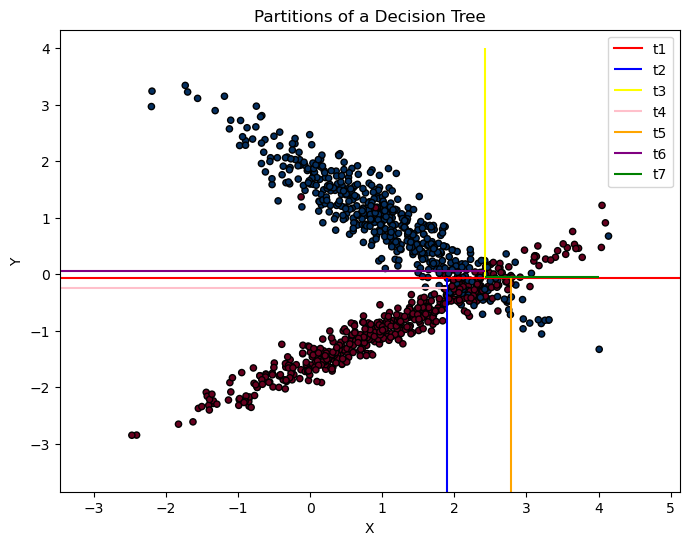

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification

# Generate random dataset
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42)

# Train classifier
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

# Create grid
h = .02  # step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Prediction for each point in grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Decision boundaries
plt.figure(figsize=(8, 6))
#plt.contourf(xx, yy, Z) # Colored regions

# Plot the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.axhline(-0.074, color = 'red', label = 't1')
plt.vlines(1.904, ymin = -4, ymax = -0.074, colors = 'blue', linestyles = 'solid', label = 't2')
plt.vlines(2.427, ymin = -0.074, ymax = 4, colors = 'yellow', linestyles = 'solid', label = 't3')
plt.hlines(-0.243, xmin = -4, xmax = 1.904, colors = 'pink', linestyles = 'solid', label = 't4')
plt.vlines(2.788, ymin = -4, ymax = -0.074, colors = 'orange', linestyles = 'solid', label = 't5')
plt.hlines(0.064, xmin = -4, xmax = 2.427, colors = 'purple', linestyles = 'solid', label = 't6')
plt.hlines(-.058, xmin = 2.427, xmax = 4, colors = 'green', linestyles = 'solid', label = 't7')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Partitions of a Decision Tree")
plt.show()

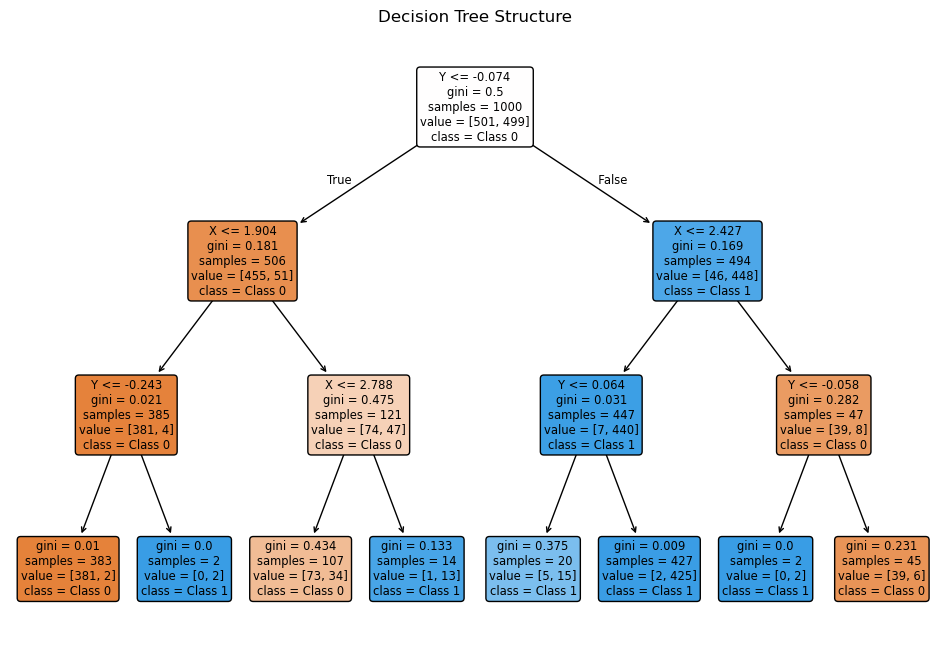

In [14]:
# Plot the tree structure
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=['X', 'Y'], class_names=['Class 0', 'Class 1'], rounded=True)
plt.title("Decision Tree Structure")
plt.show()